In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

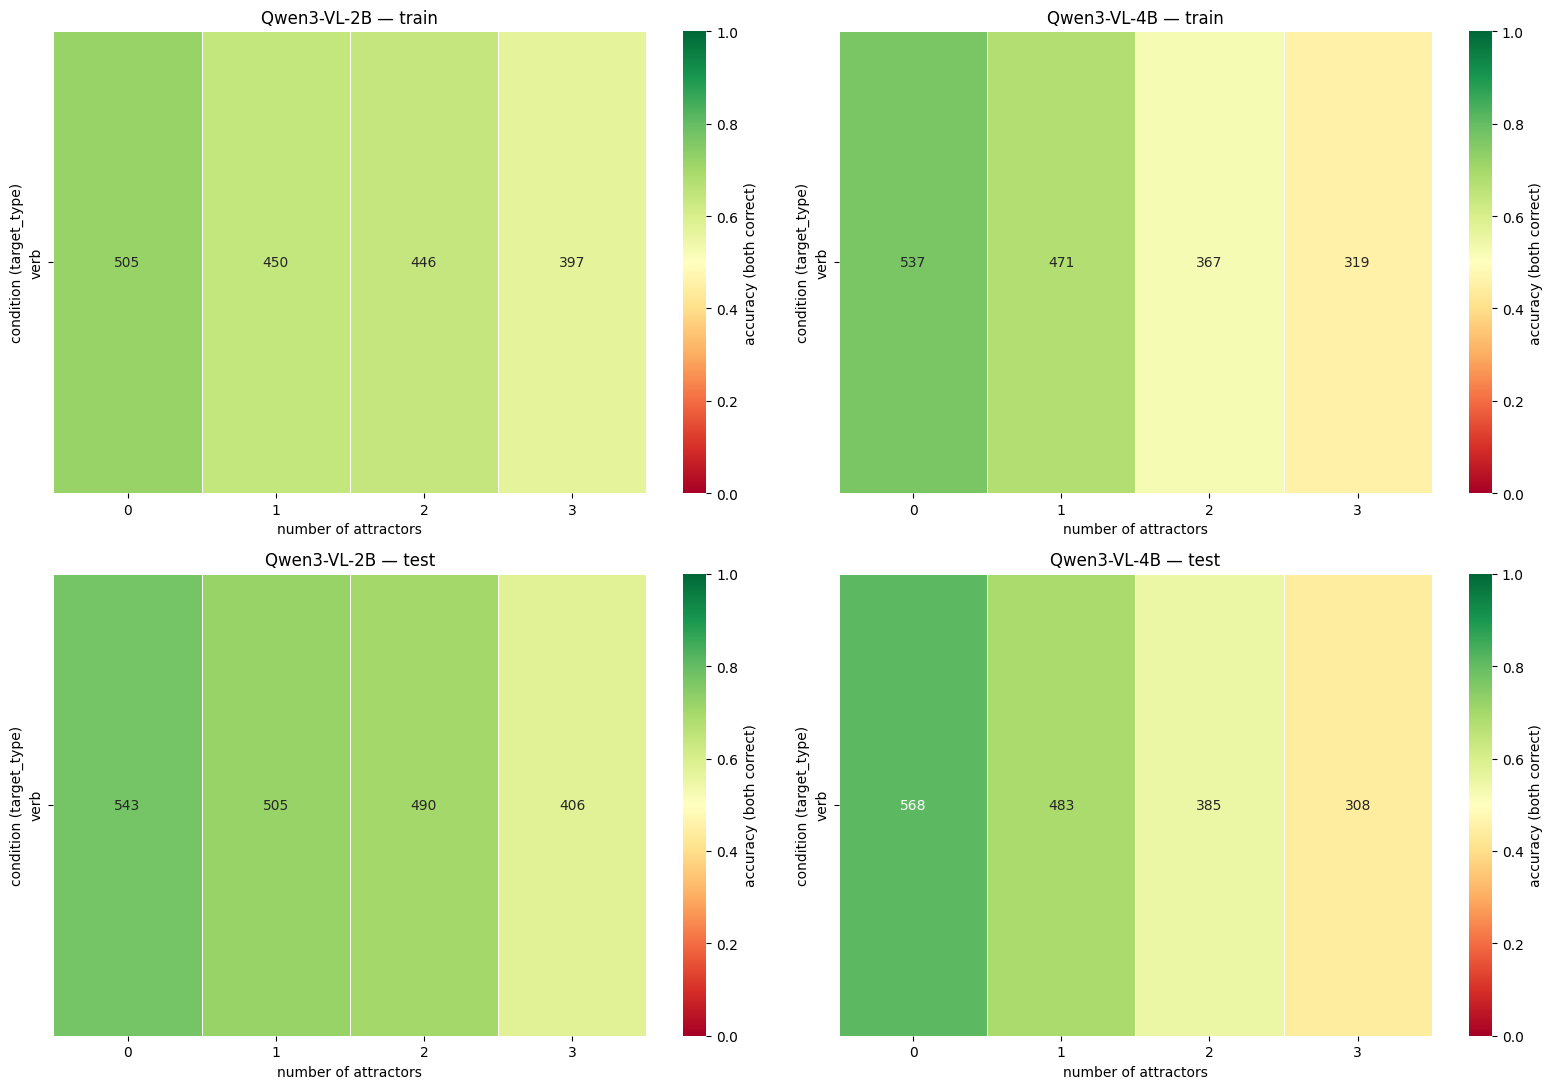

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

paths = {
    "Qwen3-VL-2B": "../../results/eval/interp/Qwen3-VL-2B-Instruct/agreement_target_natural_scored.csv",
    "Qwen3-VL-4B": "../../results/eval/interp/Qwen3-VL-4B-Instruct/agreement_target_natural_scored.csv",
}

splits = ["train", "test"]

fig, axes = plt.subplots(len(splits), len(paths), figsize=(16, 11))

for r, split in enumerate(splits):
    for c, (name, path) in enumerate(paths.items()):
        ax = axes[r, c]
        df = pd.read_csv(path)
        df = df[df["split"] == split]

        grp = df.groupby(["target_type", "attractors"])["is_correct_all"]
        prop  = grp.mean().unstack("attractors").sort_index()   # colors: P(both correct)
        count = grp.sum().unstack("attractors").sort_index()    # annotations: # both correct

        sns.heatmap(
            prop, ax=ax, annot=count, fmt=".0f",
            vmin=0, vmax=1, cmap="RdYlGn",
            cbar_kws={"label": "accuracy (both correct)"},
            linewidths=0.5, linecolor="white",
        )
        ax.set_title(f"{name} — {split}")
        ax.set_xlabel("number of attractors")
        ax.set_ylabel("condition (target_type)")

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# ============================================================
#  Fold a wide scored CSV into long format.
#
#  Each wide row pairs a singular item and a plural item under one
#  set_id. We emit two long rows per wide row, tagged by a new column
#  `completion_rule` in {"singular", "plural"}. Number-marked columns
#  collapse to a single base name:
#       base_sentence_sg / base_sentence_pl   -> base_sentence
#       good_singular    / good_plural        -> good
#       score_diff_singular / score_diff_plural -> score_diff
#       singular_item_id / plural_item_id     -> item_id
#  Three naming conventions are recognised:
#       suffix  _sg / _pl
#       suffix  _singular / _plural
#       prefix  singular_ / plural_
#  Columns with no number marker (idx, split, target_type, attractors,
#  condition, set_id, is_correct_all, ...) are shared and duplicated.
# ============================================================

# longer suffixes first so "_singular" wins over "_sg"
_SUFFIX = [('_singular', 'singular'), ('_plural', 'plural'),
           ('_sg', 'singular'), ('_pl', 'plural')]
_PREFIX = [('singular_', 'singular'), ('plural_', 'plural')]

def classify(col):
    """Return (base_name, rule) for a number-marked column, else (None, None)."""
    for suf, rule in _SUFFIX:
        if col.endswith(suf):
            return col[:-len(suf)], rule
    for pre, rule in _PREFIX:
        if col.startswith(pre):
            return col[len(pre):], rule
    return None, None

def fold_long(df):
    cols = list(df.columns)

    # group number-marked columns by their base name
    bases = {}
    for c in cols:
        base, rule = classify(c)
        if base is not None:
            bases.setdefault(base, {})[rule] = c

    shared = [c for c in cols if classify(c)[0] is None]

    # build one sub-frame per rule, then stack
    frames = []
    for rule in ('singular', 'plural'):
        sub = df[shared].copy()
        for base, mapping in bases.items():
            sub[base] = df[mapping[rule]].values if rule in mapping else pd.NA
        sub['completion_rule'] = rule
        frames.append(sub)
    long_df = pd.concat(frames, ignore_index=True)

    # tidy column order: original positions preserved, base name placed
    # where its first variant appeared, completion_rule last
    ordered, seen = [], set()
    for c in cols:
        base, _ = classify(c)
        if base is None:
            ordered.append(c)
        elif base not in seen:
            ordered.append(base); seen.add(base)
    ordered.append('completion_rule')
    return long_df[ordered]


paths = {
    "Qwen3-VL-2B": "../../results/eval/interp/Qwen3-VL-2B-Instruct/agreement_target_natural_scored.csv",
    "Qwen3-VL-4B": "../../results/eval/interp/Qwen3-VL-4B-Instruct/agreement_target_natural_scored.csv",
}

for name, path in paths.items():
    df = pd.read_csv(path)
    long_df = fold_long(df)

    out_path = path.replace(".csv", "_long.csv")
    long_df.to_csv(out_path, index=False)

    # ---- check: long CSV is exactly twice as long as the original ----
    assert len(long_df) == 2 * len(df), (
        f"{name}: expected {2 * len(df)} rows, got {len(long_df)}"
    )
    print(f"{name}: {len(df)} wide rows -> {len(long_df)} long rows "
          f"(exactly 2x: {len(long_df) == 2 * len(df)})  ->  {out_path}")

print("\nall files confirmed exactly 2x original length")

Qwen3-VL-2B: 5600 wide rows -> 11200 long rows (exactly 2x: True)  ->  ../../results/eval/interp/Qwen3-VL-2B-Instruct/agreement_target_natural_scored_long.csv
Qwen3-VL-4B: 5600 wide rows -> 11200 long rows (exactly 2x: True)  ->  ../../results/eval/interp/Qwen3-VL-4B-Instruct/agreement_target_natural_scored_long.csv

all files confirmed exactly 2x original length


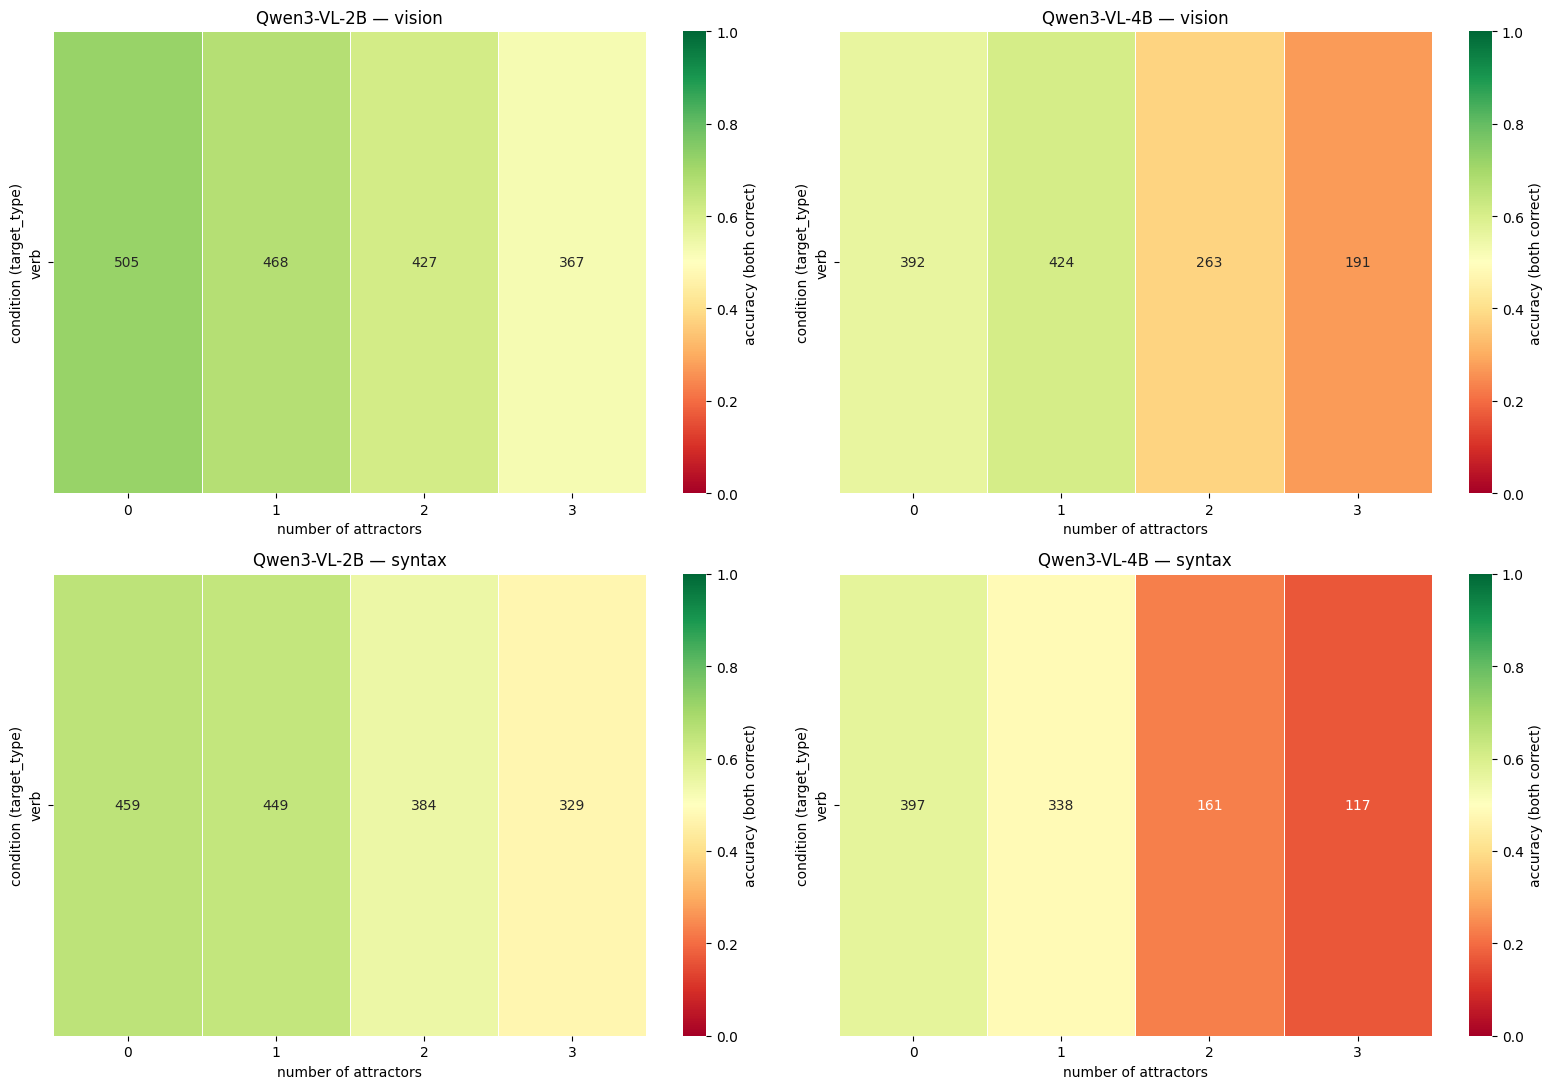

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Qwen3-VL-2B": "Qwen3-VL-2B-Instruct",
    "Qwen3-VL-4B": "Qwen3-VL-4B-Instruct",
}
embed_types = ["vision", "syntax"]

base = "../../results/eval/interp"
fname = "agreement_target_wug_scored.csv"

fig, axes = plt.subplots(len(embed_types), len(models), figsize=(16, 11))

for r, etype in enumerate(embed_types):
    for c, (name, model_dir) in enumerate(models.items()):
        ax = axes[r, c]
        path = f"{base}/{model_dir}/{etype}/{fname}"
        df = pd.read_csv(path)

        grp = df.groupby(["target_type", "attractors"])["is_correct_all"]
        prop  = grp.mean().unstack("attractors").sort_index()   # colors: P(both correct)
        count = grp.sum().unstack("attractors").sort_index()    # annotations: # both correct

        sns.heatmap(
            prop, ax=ax, annot=count, fmt=".0f",
            vmin=0, vmax=1, cmap="RdYlGn",
            cbar_kws={"label": "accuracy (both correct)"},
            linewidths=0.5, linecolor="white",
        )
        ax.set_title(f"{name} — {etype}")
        ax.set_xlabel("number of attractors")
        ax.set_ylabel("condition (target_type)")

plt.tight_layout()
plt.show()